## 1. Data collection
## 2. EDA of the data
## 3. Preprocessing of the data
## 4. Model(arima,sarima,sarimax)
## 5. Evaluation of the model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.stattools import adfuller

In [2]:
stock_data=pd.read_csv(r"C:\Users\monika Bhati\Downloads\tsla_raw_data.csv")

In [3]:
stock_data.head()

,date,open,high,low,close,volume,adjusted_close,change_percent,avg_vol_20d
0,2010-06-29,18.9999,24.9999,17.5401,23.8899,18783278,1.5927,NaN,NaN
1,2010-06-30,25.7901,30.4191,23.3001,23.8299,17194392,1.5887,-0.25,NaN
2,2010-07-01,24.9999,25.9200,20.2701,21.9600,8229862,1.4640,-7.85,NaN
3,2010-07-02,23.0001,23.1000,18.7101,19.2000,5141806,1.2800,-12.57,NaN
4,2010-07-06,20.0001,20.0001,15.8301,16.1100,6879295,1.0740,-16.09,NaN


In [4]:
stock_data=stock_data[["date","close"]]

In [5]:
stock_data

,date,close
0,2010-06-29,23.8899
1,2010-06-30,23.8299
2,2010-07-01,21.9600
3,2010-07-02,19.2000
4,2010-07-06,16.1100
...,...,...
3467,2024-04-09,176.8800
3468,2024-04-10,171.7600
3469,2024-04-11,174.6000
3470,2024-04-12,171.0500


In [6]:
stock_data.info()        

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3472 non-null   object 
 1   close   3472 non-null   float64
dtypes: float64(1), object(1)
memory usage: 54.4+ KB


In [7]:
# we don't want string so will type caste it

stock_data["date"]=pd.to_datetime(stock_data.date)

In [8]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3472 non-null   datetime64[ns]
 1   close   3472 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 54.4 KB


In [9]:
# convert date col as index col

stock_data=stock_data.set_index("date")

In [10]:
stock_data

,close
date,
2010-06-29,23.8899
2010-06-30,23.8299
2010-07-01,21.9600
2010-07-02,19.2000
2010-07-06,16.1100
...,...
2024-04-09,176.8800
2024-04-10,171.7600
2024-04-11,174.6000


## why we make it date as a index column
1. retriving of the data will be easy

2. visualization

3. statamodel scipy

4. time based calculation

## Exploratory DAta Analysis

1. summary statistics

computer summary statistics such as mean,median,mode,standard deviation,to get an overview of the data

2. visualize the time series data

plot the time series data

plot the rolling mean and rolling standard deviation of time series data.

decompose the time series data check for any trends,seasonality and noise.

plot the decomposed to get a better understanding of the time series data.

3. stationary check

check for stationary

check for stationarity of the time series data using the augmented dickey-fuller test.

4. check for autocorrelation

plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) to identify the order of the ARIMA model

5. outlier detection

detect and handle outlier using statistical methods or machine learning techniques.

6. check for partial autocorrelation

plot the autocorrelation function (ACF) and PACF to identify the order of the ARIMA model.


In [11]:
stock_data["close"].describe().T     # describe()-Gives statistical summary of numerical data.

#transposes rows ↔ columns.

count    3472.000000
mean      305.740220
std       289.265494
min        15.800100
25%       153.360000
50%       232.995050
75%       335.967450
max      2238.750000
Name: close, dtype: float64

(array([1792., 1076.,  163.,  273.,  114.,   14.,   26.,    4.,    5.,
           5.]),
 array([  15.8001 ,  238.09509,  460.39008,  682.68507,  904.98006,
        1127.27505, 1349.57004, 1571.86503, 1794.16002, 2016.45501,
        2238.75   ]),
 <BarContainer object of 10 artists>)

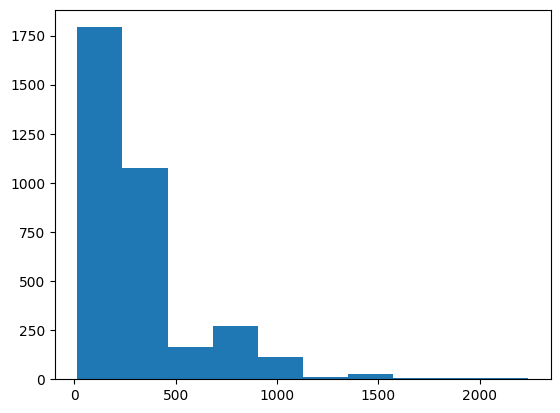

In [12]:
#to visualize the data

plt.hist(stock_data["close"])

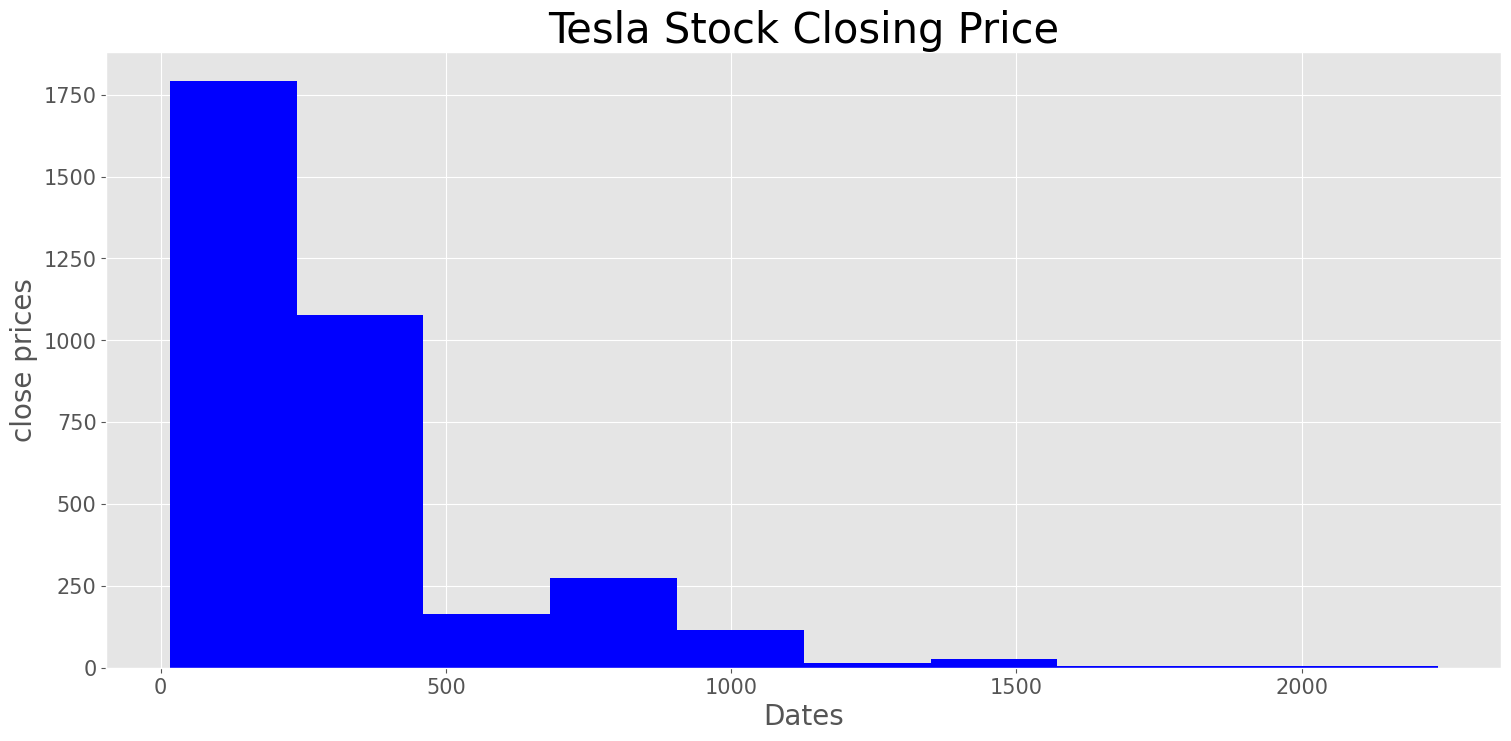

In [13]:
# plotting close price

plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates',fontsize=20)
plt.xticks(fontsize=15)
plt.ylabel('close prices',fontsize=20)
plt.yticks(fontsize=15)
plt.hist(stock_data['close'],linewidth=3,color='blue')
plt.title('Tesla Stock Closing Price',fontsize=30)
plt.show()

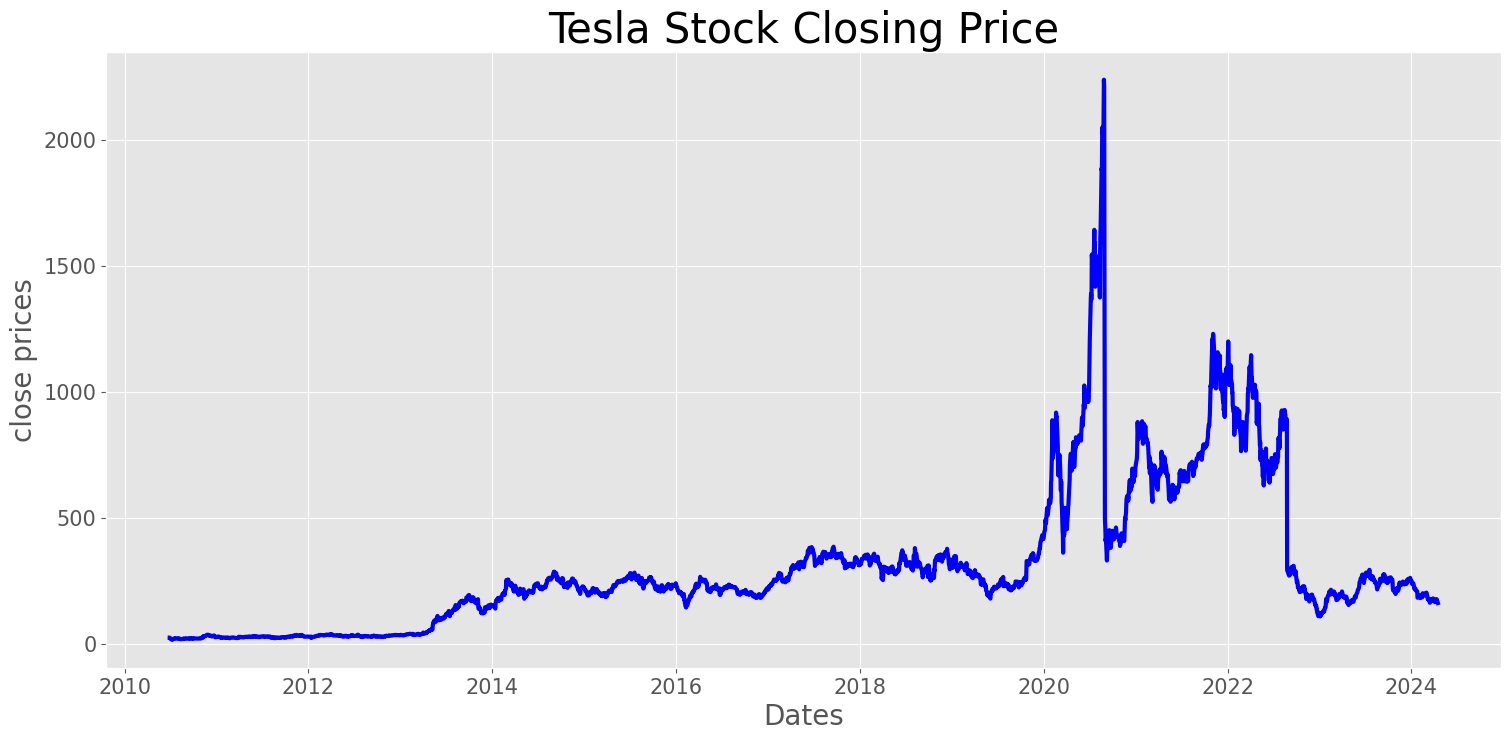

In [14]:
# plotting close price

plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel('Dates',fontsize=20)
plt.xticks(fontsize=15)
plt.ylabel('close prices',fontsize=20)
plt.yticks(fontsize=15)
plt.plot(stock_data['close'],linewidth=3,color='blue')
plt.title('Tesla Stock Closing Price',fontsize=30)
plt.show()

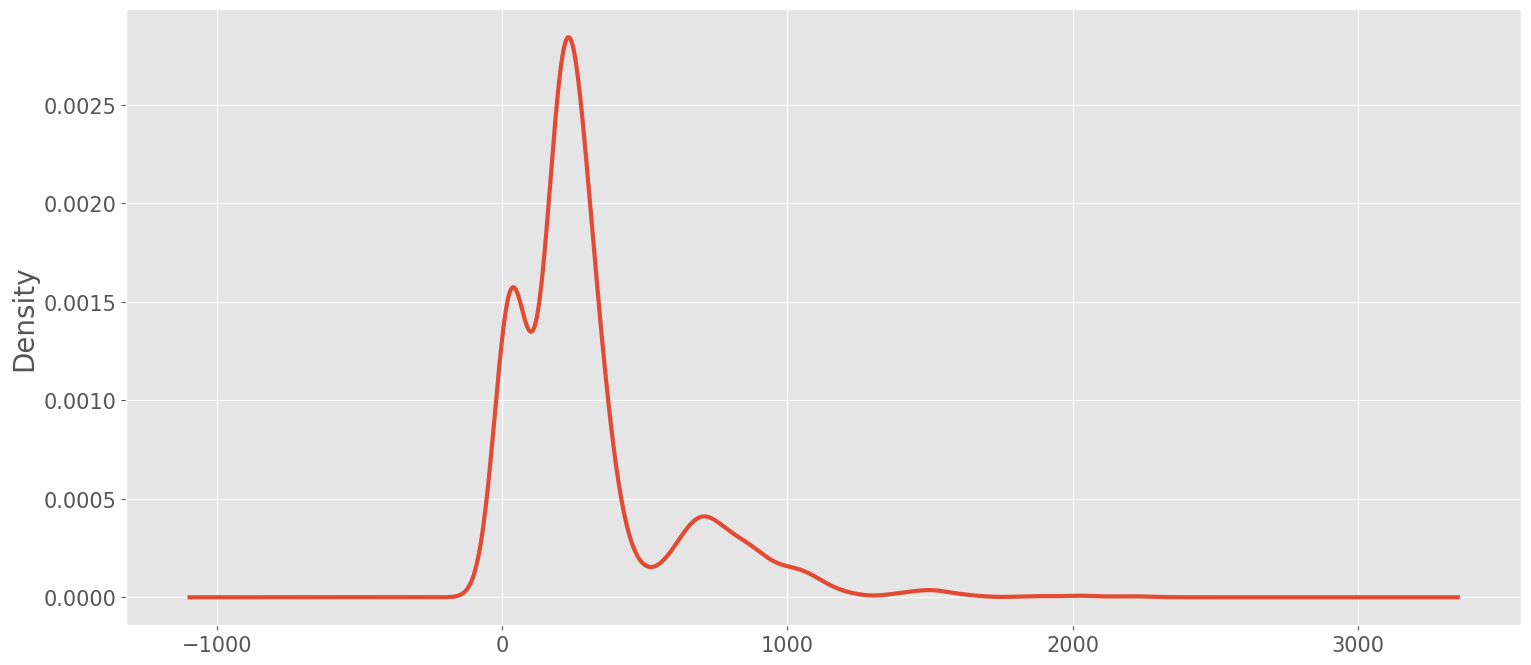

In [15]:
# distribution of the close price

df_close =stock_data['close']
df_close.plot(kind='kde',figsize=(18,8),linewidth=3)    #KDE(Kernel Density Estimation) is a smooth curve version of a histogram
plt.xticks(fontsize=15)
plt.grid("both")
plt.ylabel('Density',fontsize=20)
plt.yticks(fontsize=15)
plt.show()

In [16]:
# rolling statistics- why?--bcoz we want to smooth the data

rollmean=stock_data["close"].rolling(150).mean()     # 12-window size and it can be anything

In [17]:
stock_data["close"].rolling(24).mean()

date
2010-06-29           NaN
2010-06-30           NaN
2010-07-01           NaN
2010-07-02           NaN
2010-07-06           NaN
                 ...    
2024-04-09    172.826667
2024-04-10    172.627500
2024-04-11    172.458750
2024-04-12    172.280000
2024-04-15    171.601250
Name: close, Length: 3472, dtype: float64

In [18]:
stock_data["close"].rolling(100).mean()

date
2010-06-29         NaN
2010-06-30         NaN
2010-07-01         NaN
2010-07-02         NaN
2010-07-06         NaN
                ...   
2024-04-09    209.1834
2024-04-10    208.5269
2024-04-11    207.8445
2024-04-12    207.2191
2024-04-15    206.4909
Name: close, Length: 3472, dtype: float64

In [19]:
rolstd=stock_data["close"].rolling(12).std()

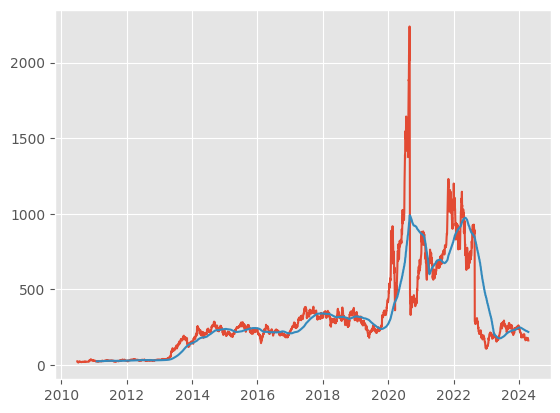

In [20]:
plt.plot(stock_data["close"])
plt.plot(rollmean)

In [21]:
rollmean.head(150)

date
2010-06-29          NaN
2010-06-30          NaN
2010-07-01          NaN
2010-07-02          NaN
2010-07-06          NaN
                ...    
2011-01-25          NaN
2011-01-26          NaN
2011-01-27          NaN
2011-01-28          NaN
2011-01-31    23.648558
Name: close, Length: 150, dtype: float64

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller


In [23]:
from statsmodels.tsa.stattools import adfuller

# Test for stationarity
def test_stationarity(timeseries):

    # 1️Determining rolling statistics
    rolmean = timeseries.rolling(window=365).mean()   # rolling mean
    rolstd  = timeseries.rolling(window=365).std()    # rolling standard deviation

    # Plot rolling statistics
    plt.figure(figsize=(18, 8))
    plt.grid('both')

    plt.plot(timeseries, color='blue', label='Original', linewidth=3)
    plt.plot(rolmean, color='red', label='Rolling Mean', linewidth=3)
    plt.plot(rolstd, color='black', label='Rolling Std', linewidth=4)

    plt.legend(
        loc='best',
        fontsize=20,
        shadow=True,
        facecolor='lightpink',
        edgecolor='k'
    )

    plt.title('Rolling Mean and Standard Deviation', fontsize=25)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show(block=False)

    # Perform Dickey-Fuller test
    print("Results of Dickey-Fuller Test:")
    adf = adfuller(timeseries, autolag='AIC')
    # output for dft will give us without defining what the values are
    # hence we manually write what values does it explains using a for loop
    output = pd.Series(
        adf[0:4],
        index=[
            'Test Statistic',
            'p-value',
            'No. of lags used',
            'Number of observations used'
        ]
    )

    # 4️Add critical values
    for key, value in adf[4].items():
        output[f'Critical Value ({key})'] = value

    print(output)


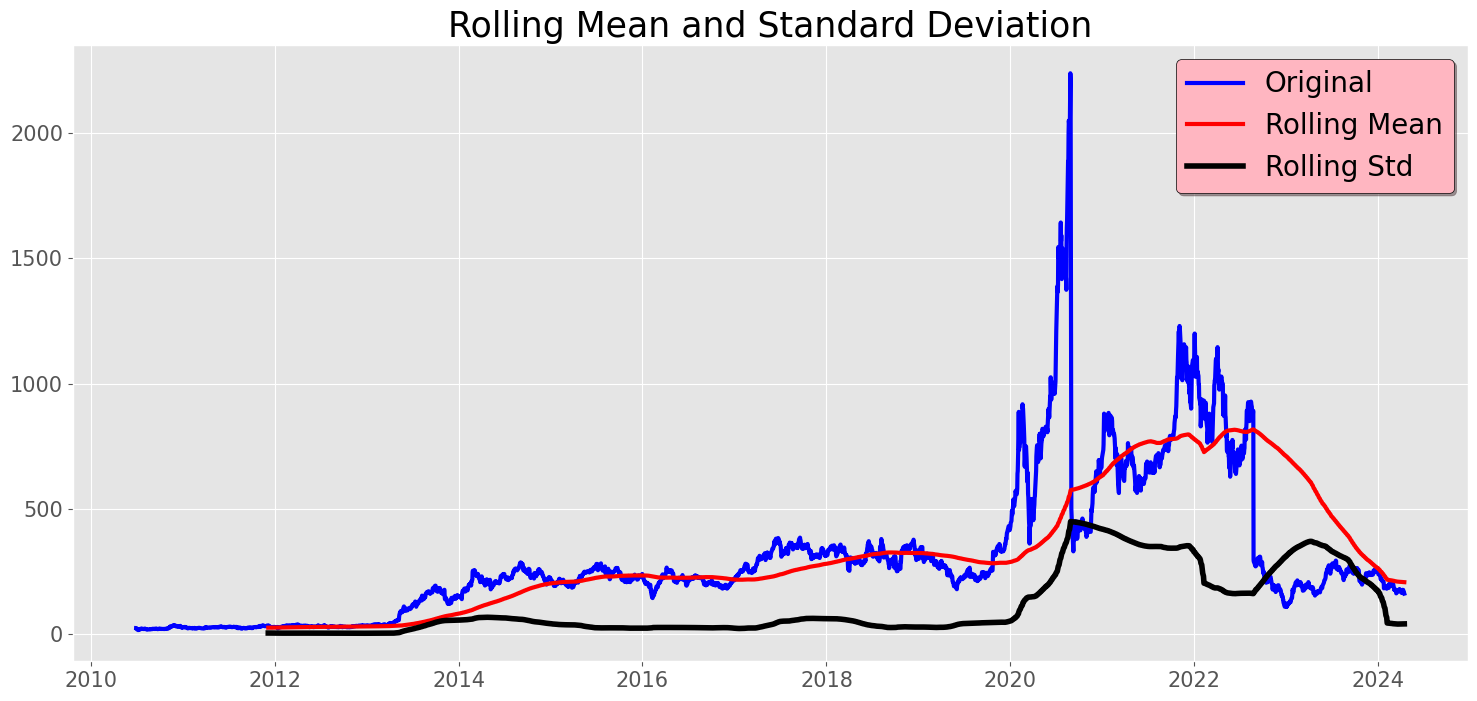

Results of Dickey-Fuller Test:
Test Statistic                   -3.024298
p-value                           0.032687
No. of lags used                 30.000000
Number of observations used    3441.000000
Critical Value (1%)              -3.432252
Critical Value (5%)              -2.862380
Critical Value (10%)             -2.567217
dtype: float64


In [24]:
test_stationarity(stock_data["close"])

## dickeyfullar test

## we perform th adf test for checking if my data is stationary or non stationary . 
## if my value is less than p<0.05 so my data is station
## if my p value is greater than p>0.05 so my dta will be non stationary

In [25]:
from statsmodels.tsa.stattools import adfuller
adft=adfuller(stock_data['close'])

In [26]:
adft

(np.float64(-3.024297883905241),
 np.float64(0.03268674929621701),
 30,
 3441,
 {'1%': np.float64(-3.432251826486971),
  '5%': np.float64(-2.8623803178837206),
  '10%': np.float64(-2.5672173165743857)},
 np.float64(34276.25452120248))

In [27]:
output = pd.Series(
        adft[0:4],
        index=[
            'Test Statistic',
            'p-value',
            'No. of lags used',
            'Number of observations used'
        ]
    )

In [28]:
output

Test Statistic                   -3.024298
p-value                           0.032687
No. of lags used                 30.000000
Number of observations used    3441.000000
dtype: float64

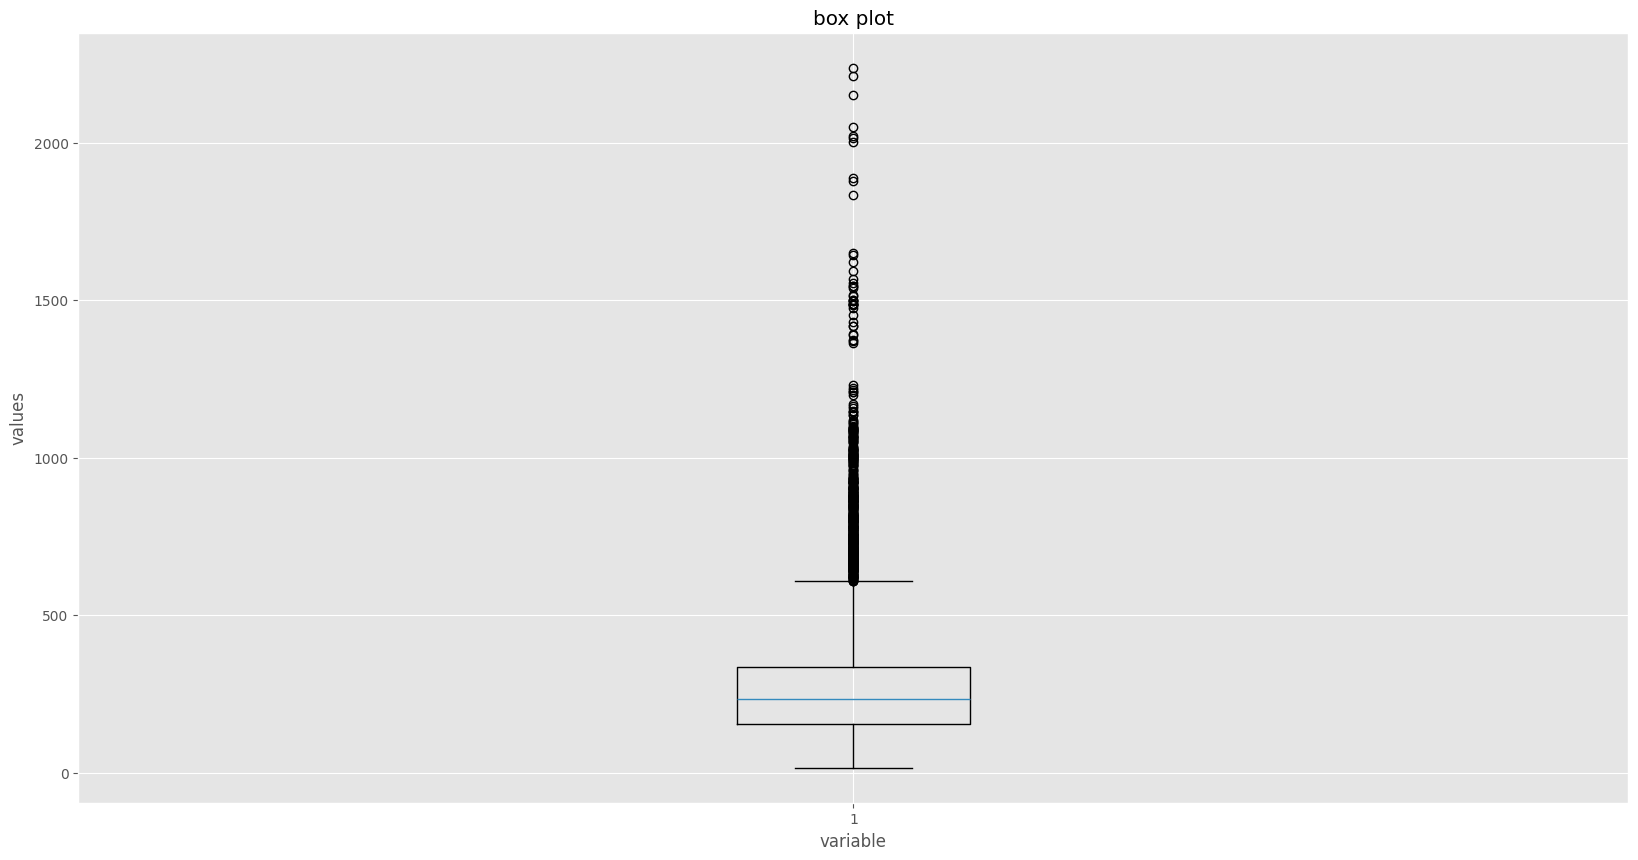

In [29]:
#outlier
fig,ax=plt.subplots(figsize=(20,10))
# plot the box plot
ax.boxplot(stock_data["close"])
# set the x-axis label
ax.set_xlabel('variable')
# set the y-axis label
ax.set_ylabel('values')
#set the title
ax.set_title('box plot')
#show the plot
plt.show()

## Acf and pacf

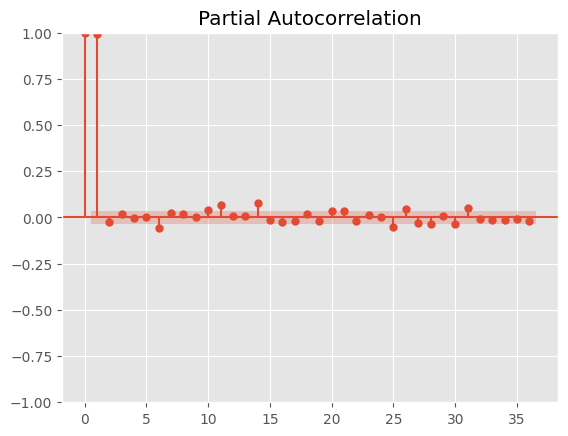

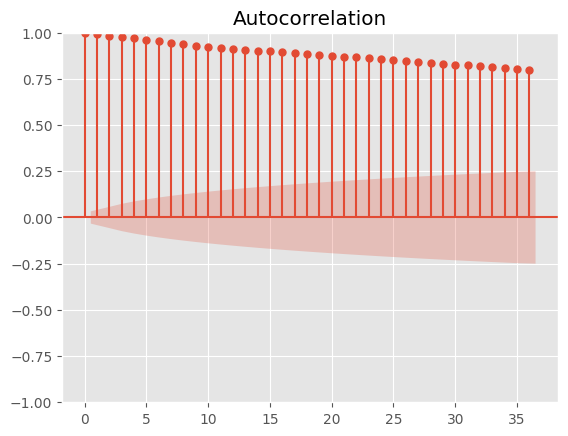

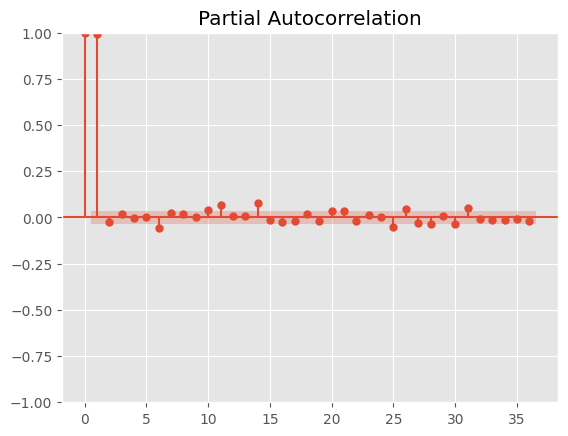

In [30]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_acf(stock_data['close'])
plot_pacf(stock_data['close'])

## plot arima model

In [31]:
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [32]:
train_data=stock_data["close"][0:-60]
test_data=stock_data["close"][-60:]

In [33]:
train_data

date
2010-06-29     23.8899
2010-06-30     23.8299
2010-07-01     21.9600
2010-07-02     19.2000
2010-07-06     16.1100
                ...   
2024-01-11    227.2200
2024-01-12    218.8900
2024-01-16    219.9100
2024-01-17    215.5500
2024-01-18    211.8800
Name: close, Length: 3412, dtype: float64

In [34]:
stock_data.shape

(3472, 1)

In [35]:
3472-60   #train data

3412

In [36]:
test_data.shape

(60,)

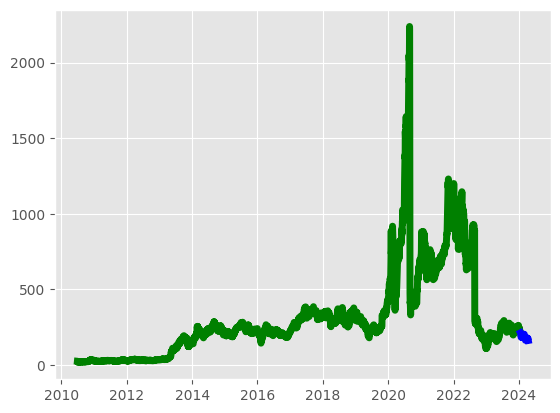

In [37]:
plt.plot(train_data,'green',label='train data',linewidth=5)
plt.plot(test_data,'blue',label='test data',linewidth=5)

In [38]:
# model building
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

history=[x for x in train_data]
model=ARIMA(history,order=(1,1,2))     #order - lag value
model_fit=model.fit()
y_forecast = model_fit.forecast()[0]
print(f"this is my forecast value: {y_forecast}")
mse = mean_squared_error([test_data[0]], [y_forecast])
print("MSE:", mse)

print(f"this is my original value:{test_data[0]}")

this is my forecast value: 211.8945169029788
MSE: 0.08731026062523406
this is my original value:212.19


## Exploratory DAta Analysis

1. summary statistics

computer summary statistics such as mean,median,mode,standard deviation,to get an overview of the data

2. visualize the time series data

plot the time series data

plot the rolling mean and rolling standard deviation of time series data.

decompose the time series data check for any trends,seasonality and noise.

plot the decomposed to get a better understanding of the time series data.

3. stationary check

check for stationary

check for stationarity of the time series data using the augmented dickey-fuller test.

4. check for autocorrelation

plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) to identify the order of the ARIMA model

5. outlier detection

detect and handle outlier using statistical methods or machine learning techniques.

6. check for partial autocorrelation

plot the autocorrelation function (ACF) and PACF to identify the order of the ARIMA model.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error


In [40]:
stock_data.info()
stock_data['close'].describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3472 entries, 2010-06-29 to 2024-04-15
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   3472 non-null   float64
dtypes: float64(1)
memory usage: 54.2 KB


count    3472.000000
mean      305.740220
std       289.265494
min        15.800100
25%       153.360000
50%       232.995050
75%       335.967450
max      2238.750000
Name: close, dtype: float64

In [41]:
print("Mean:", stock_data['close'].mean())
print("Median:", stock_data['close'].median())
print("Std:", stock_data['close'].std())


Mean: 305.7402197868663
Median: 232.99505
Std: 289.2654935470482


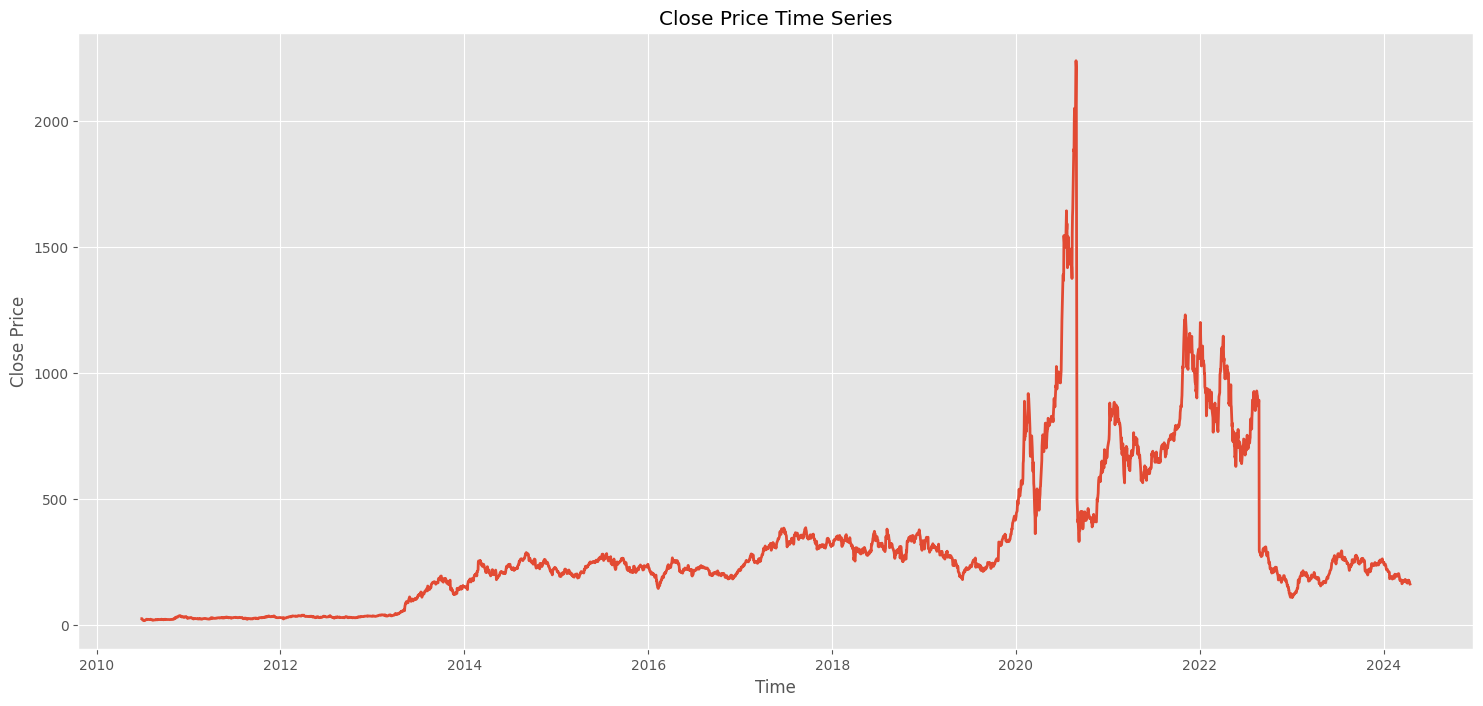

In [42]:
plt.figure(figsize=(18,8))
plt.plot(stock_data['close'], linewidth=2)
plt.title("Close Price Time Series")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()


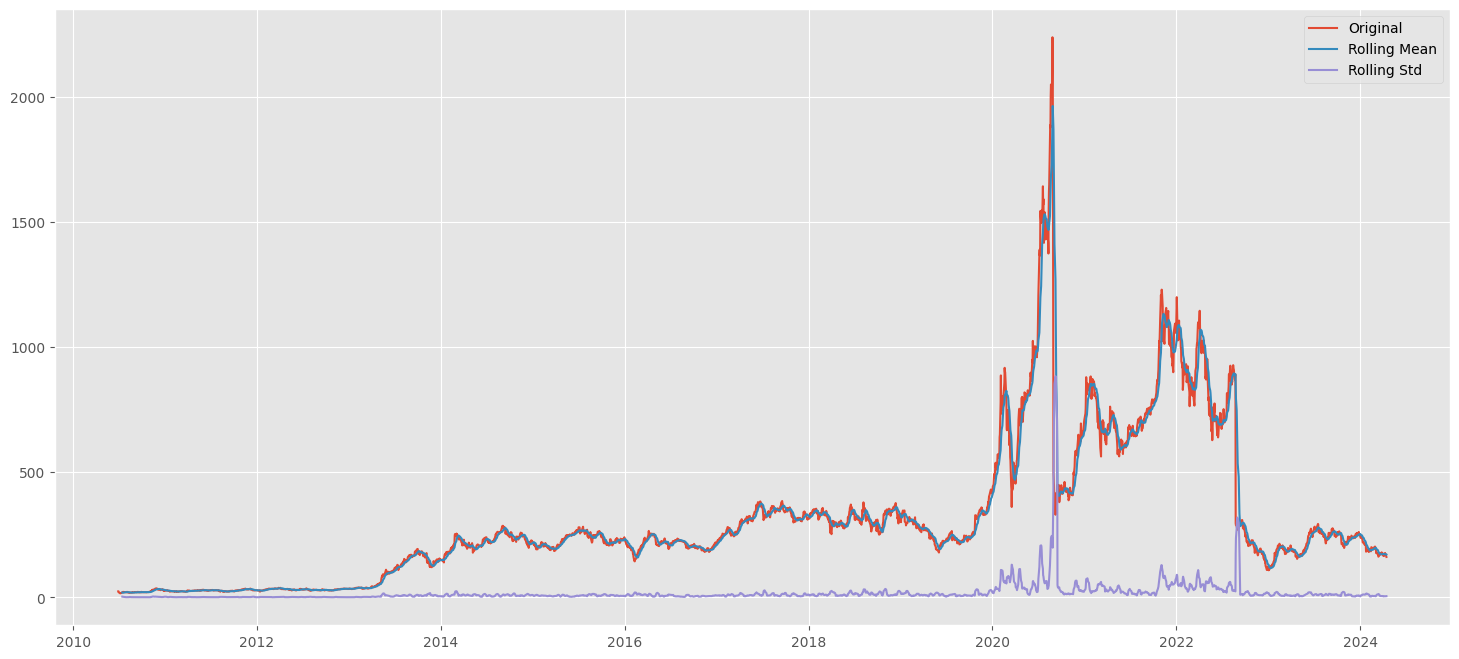

In [43]:
rolling_mean = stock_data['close'].rolling(window=12).mean()
rolling_std = stock_data['close'].rolling(window=12).std()

plt.figure(figsize=(18,8))
plt.plot(stock_data['close'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.grid(True)
plt.show()


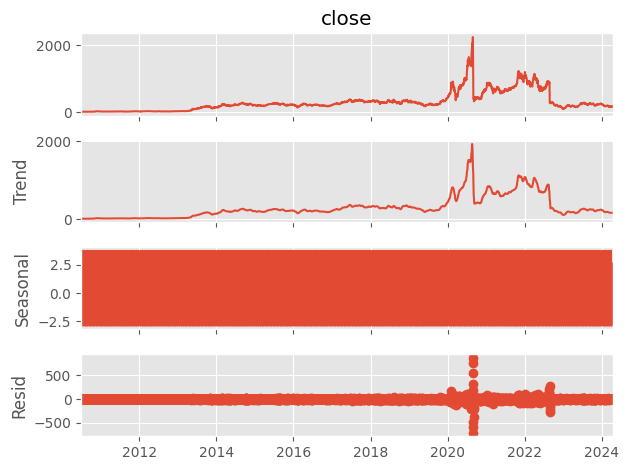

In [44]:
decomposition = seasonal_decompose(
    stock_data['close'],
    model='additive',
    period=12
)

decomposition.plot()
plt.show()


In [45]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    
    for key, value in result[4].items():
        print(f"Critical Value {key}: {value}")
        
    if result[1] <= 0.05:
        print(" Data is Stationary")
    else:
        print(" Data is Non-Stationary")

adf_test(stock_data['close'])


ADF Statistic: -3.024297883905241
p-value: 0.03268674929621701
Critical Value 1%: -3.432251826486971
Critical Value 5%: -2.8623803178837206
Critical Value 10%: -2.5672173165743857
 Data is Stationary


In [46]:
diff_close = stock_data['close'].diff().dropna()

adf_test(diff_close)


ADF Statistic: -11.635161958292537
p-value: 2.213867125572695e-21
Critical Value 1%: -3.432251826486971
Critical Value 5%: -2.8623803178837206
Critical Value 10%: -2.5672173165743857
 Data is Stationary


<Figure size 1800x500 with 0 Axes>

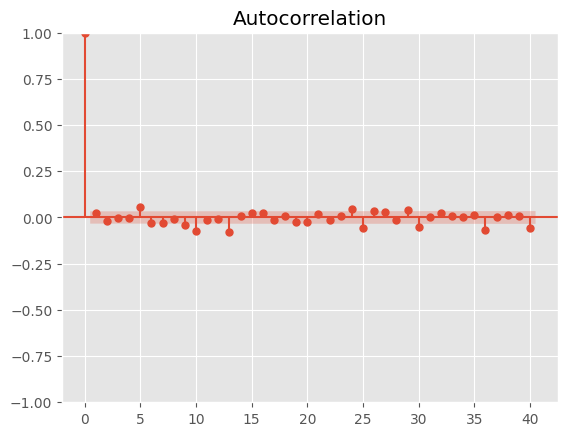

<Figure size 1800x500 with 0 Axes>

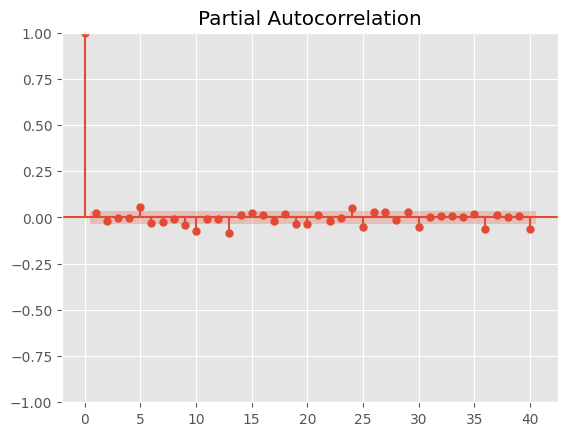

In [47]:
plt.figure(figsize=(18,5))
plot_acf(diff_close, lags=40)
plt.show()

plt.figure(figsize=(18,5))
plot_pacf(diff_close, lags=40)
plt.show()


In [48]:
train_size = int(len(stock_data) * 0.8)

train_data = stock_data['close'][:train_size]
test_data = stock_data['close'][train_size:]

print(len(train_data), len(test_data))


2777 695


In [49]:
history = list(train_data)

model = ARIMA(history, order=(1,1,2))
model_fit = model.fit()


In [53]:
predictions = []

for t in range(len(test_data)):
    model = ARIMA(history, order=(1,1,2))
    model_fit = model.fit()
    
    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat)
    
    history.append(test_data.iloc[t])


In [54]:
mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)


MSE: 27630.61962130879
RMSE: 166.2246059442127


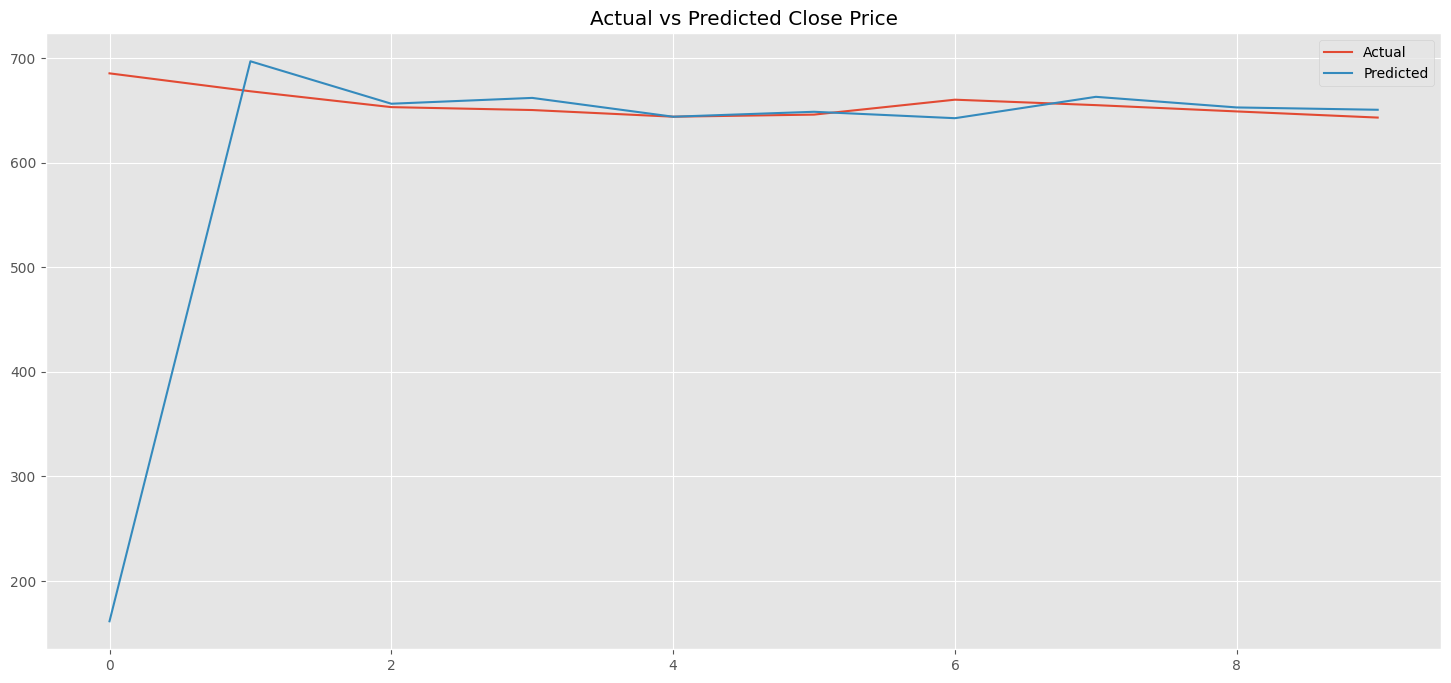

In [55]:
plt.figure(figsize=(18,8))
plt.plot(test_data.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title("Actual vs Predicted Close Price")
plt.legend()
plt.grid(True)
plt.show()


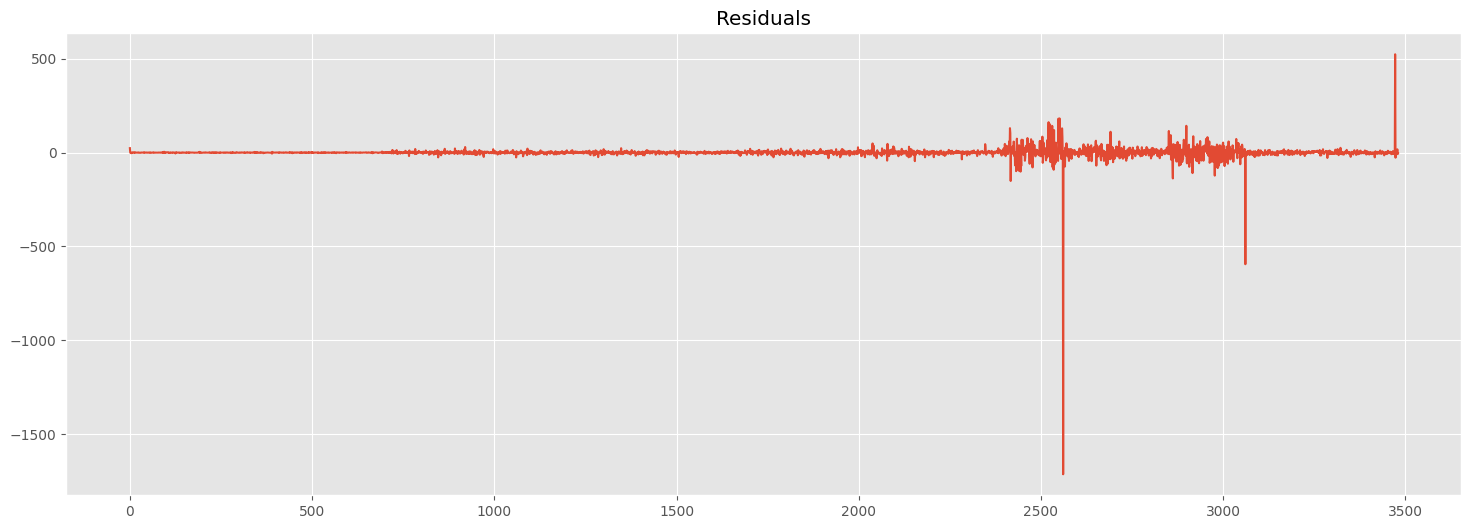

In [56]:
residuals = model_fit.resid

plt.figure(figsize=(18,6))
plt.plot(residuals)
plt.title("Residuals")
plt.grid(True)
plt.show()


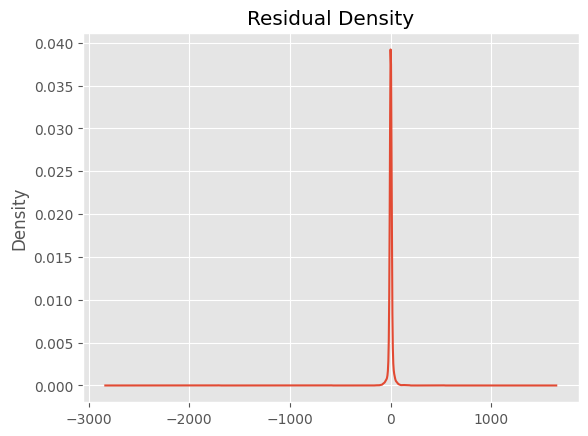

In [59]:
import pandas as pd

residuals = pd.Series(model_fit.resid)

residuals.plot(kind='kde')
plt.title("Residual Density")
plt.show()


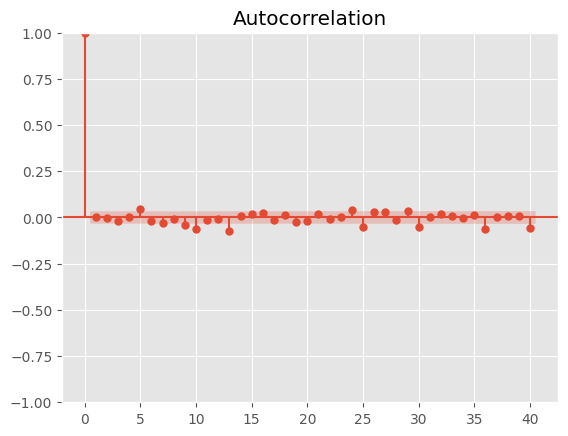

In [60]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=40)
plt.show()


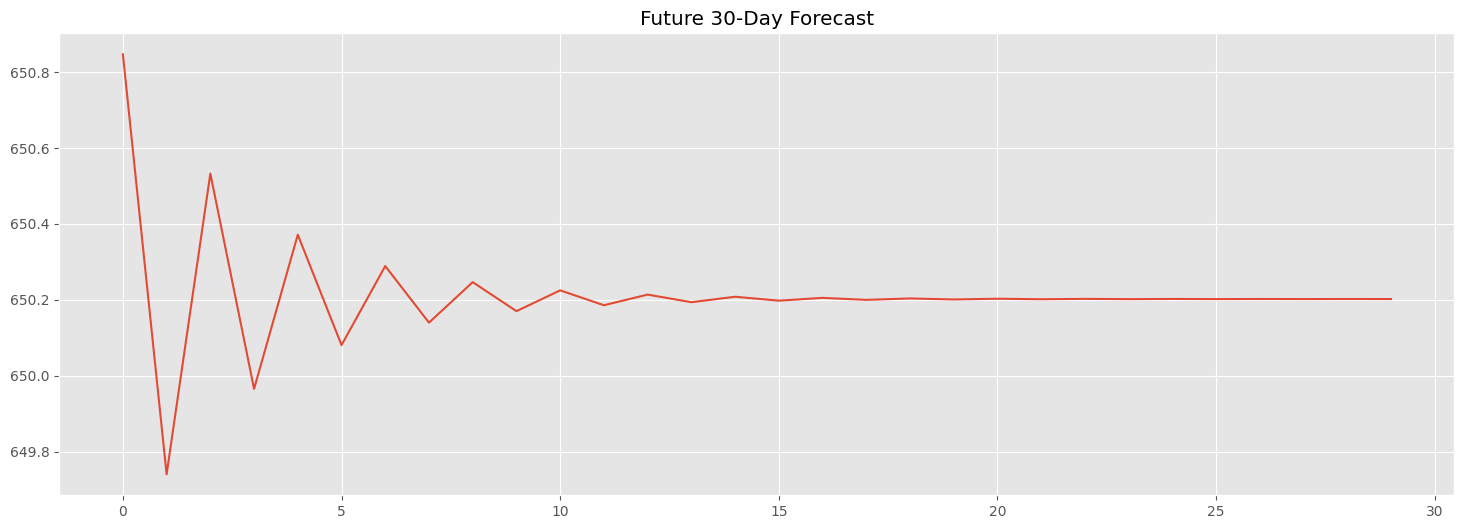

In [61]:
future_forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(18,6))
plt.plot(future_forecast)
plt.title("Future 30-Day Forecast")
plt.grid(True)
plt.show()


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

residuals = pd.Series(model_fit.resid)


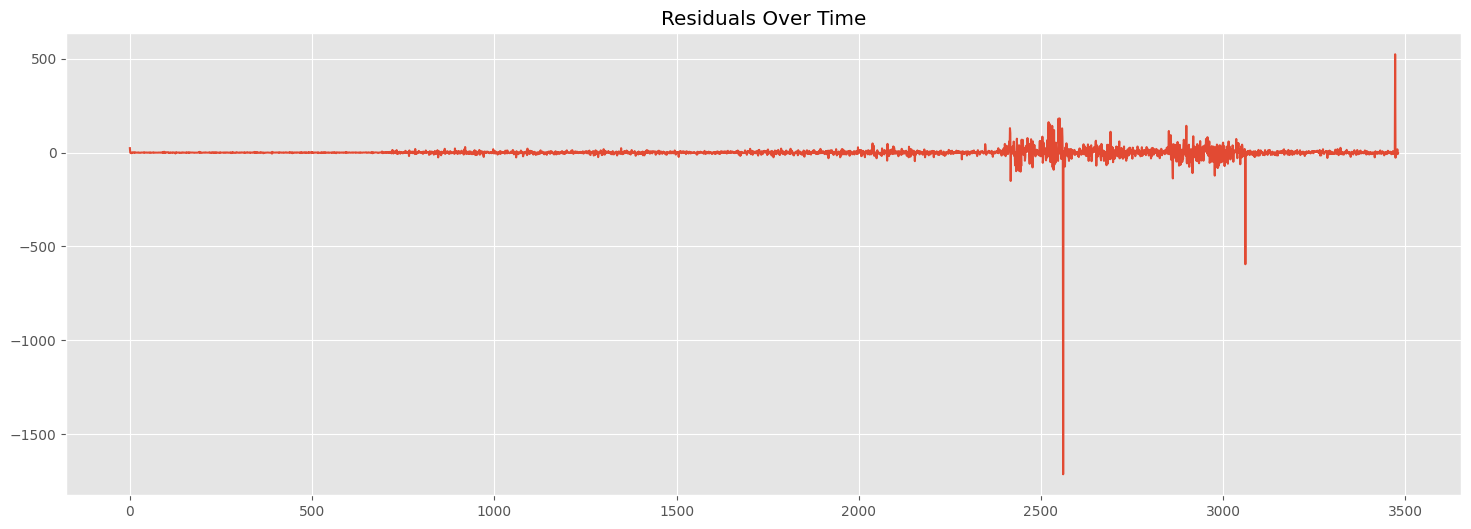

In [63]:
plt.figure(figsize=(18,6))
plt.plot(residuals)
plt.title("Residuals Over Time")
plt.grid(True)
plt.show()


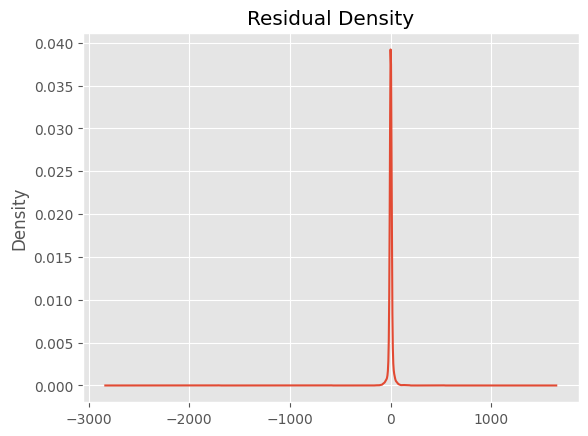

In [64]:
residuals.plot(kind='kde')
plt.title("Residual Density")
plt.show()


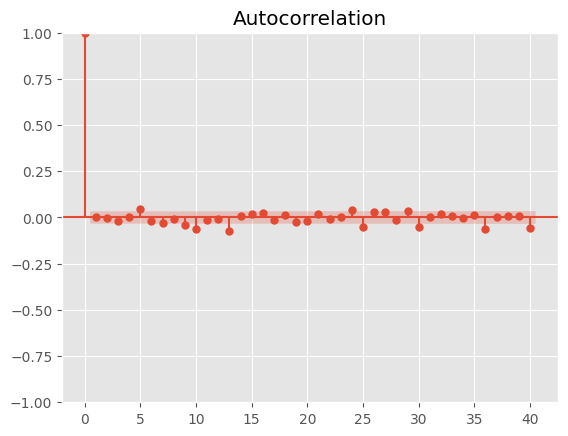

In [65]:
plot_acf(residuals, lags=40)
plt.show()


In [69]:
print(type(stock_data.index))


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [95]:
stock_data.index = pd.to_datetime(stock_data.index)
stock_data = stock_data.asfreq('B')   # for stock market


In [93]:
print(stock_data.columns)


Index(['close'], dtype='object')


In [96]:
stock_data = stock_data.asfreq('D')


In [97]:
stock_data['close'].fillna(method='ffill', inplace=True)


In [98]:
y = stock_data['close']

train_size = int(len(y)*0.8)
train = y.iloc[:train_size]
test = y.iloc[train_size:]


In [99]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)


In [100]:
forecast = model_fit.forecast(steps=len(test))


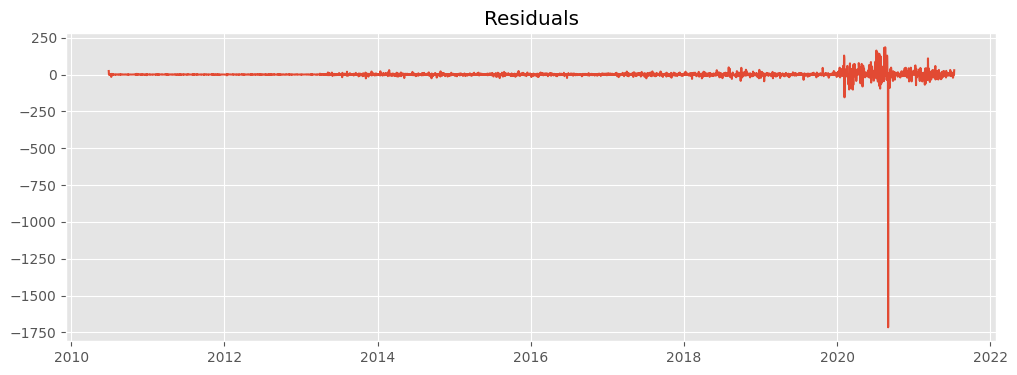

In [101]:
residuals = model_fit.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()


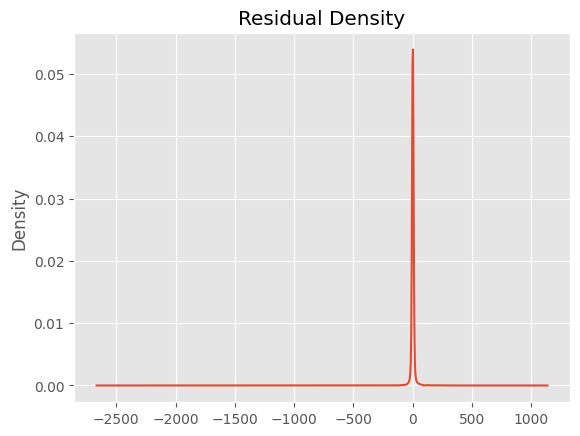

In [102]:
import pandas as pd

residuals = pd.Series(residuals)
residuals.plot(kind='kde')
plt.title("Residual Density")
plt.show()


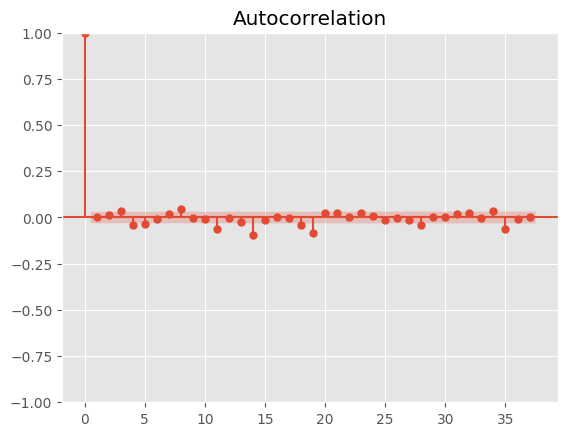

In [103]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals)
plt.show()


In [104]:
train_size = int(len(stock_data) * 0.8)
train = stock_data['close'][:train_size]
test = stock_data['close'][train_size:]


In [105]:
forecast = model_fit.forecast(steps=len(test))


In [106]:
test_clean = test.dropna()
forecast_clean = forecast[:len(test_clean)]


In [107]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(test_clean, forecast_clean)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)


MSE: 252469.48860386226
RMSE: 502.46342016495316


In [108]:
y = stock_data['close'].dropna()

train_size = int(len(y) * 0.8)
train = y.iloc[:train_size]
test = y.iloc[train_size:]


In [109]:
forecast_clean = pd.Series(
    forecast_clean,
    index=test_clean.index
)


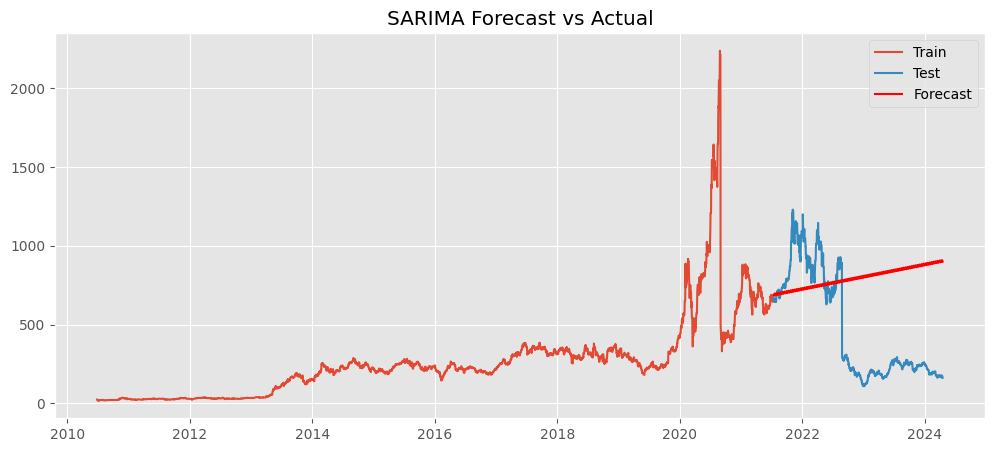

In [110]:
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast_clean, label="Forecast", color='red')
plt.legend()
plt.title("SARIMA Forecast vs Actual")
plt.show()
